In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

#  Carregar os dados
df = pd.read_csv("../dataset/IMDB Dataset.csv")

#  Converter sentimentos para 0 e 1
df["sentiment"] = df["sentiment"].map({"positive": 1, "negative": 0})

#  Transformar texto em números (TF-IDF)
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_tfidf = vectorizer.fit_transform(df["review"])
y = df["sentiment"]

#  Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (40000, 5000)
Teste: (10000, 5000)


In [3]:
from sklearn.neural_network import MLPClassifier

# Criando a Rede Neural com 1 camada de 50 neurônios
modelo_mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, random_state=42, verbose=True)

# Treinando o modelo
print("Iniciando o treinamento do MLP... Aguarde.")
modelo_mlp.fit(X_train, y_train)
print("Treinamento concluído!")

Iniciando o treinamento do MLP... Aguarde.
Iteration 1, loss = 0.47909625
Iteration 2, loss = 0.27333746
Iteration 3, loss = 0.23389312
Iteration 4, loss = 0.21768838
Iteration 5, loss = 0.20881471
Iteration 6, loss = 0.20318235
Iteration 7, loss = 0.19883025
Iteration 8, loss = 0.19542786
Iteration 9, loss = 0.19306280
Iteration 10, loss = 0.19123296
Iteration 11, loss = 0.18877533
Iteration 12, loss = 0.18706906
Iteration 13, loss = 0.18526290
Iteration 14, loss = 0.18391846
Iteration 15, loss = 0.18135404
Iteration 16, loss = 0.17929374
Iteration 17, loss = 0.17738065
Iteration 18, loss = 0.17473870
Iteration 19, loss = 0.17230510
Iteration 20, loss = 0.16903587
Treinamento concluído!


c:\Users\ricar\Documents\teste\Trabalho IA\2º Bimestre\trabalho-IA-2-Bim\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [4]:
from sklearn.metrics import accuracy_score, classification_report

# Fazendo as previsões
pred_mlp = modelo_mlp.predict(X_test)

# Verificando a acurácia
acc_mlp = accuracy_score(y_test, pred_mlp)
print(f"Acurácia MLP: {acc_mlp:.4f}")

# Relatório completo
print("\nRelatório de Classificação:")
print(classification_report(y_test, pred_mlp))

Acurácia MLP: 0.8702

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4961
           1       0.87      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



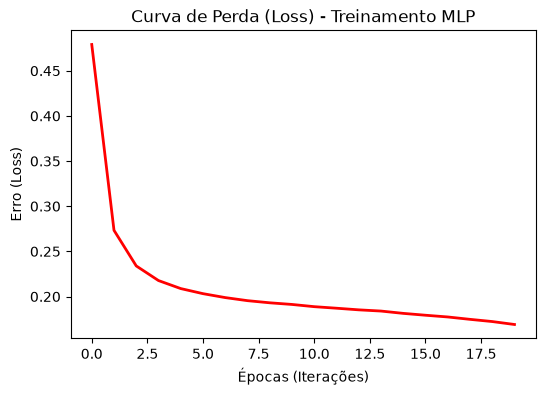

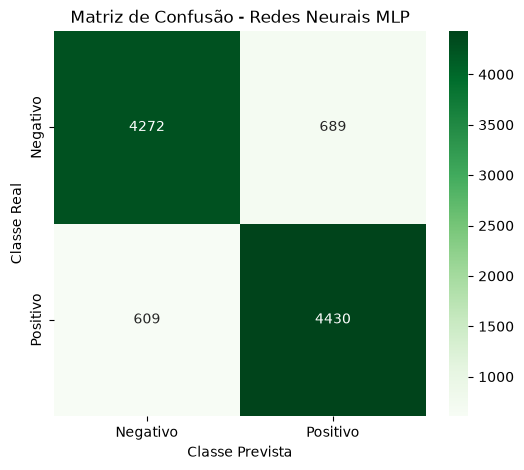

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#  Gráfico da Curva de Perda (Loss Curve)
plt.figure(figsize=(6,4))
plt.plot(modelo_mlp.loss_curve_, color='red', linewidth=2)
plt.title("Curva de Perda (Loss) - Treinamento MLP")
plt.xlabel("Épocas (Iterações)")
plt.ylabel("Erro (Loss)")
plt.show()

#  Gráfico da Matriz de Confusão
cm_mlp = confusion_matrix(y_test, pred_mlp)
plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt="d", cmap="Greens", 
            xticklabels=["Negativo", "Positivo"], 
            yticklabels=["Negativo", "Positivo"])
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão - Redes Neurais MLP")
plt.show()